# Summary
WHH Model fitting using python and `scipy.optimize.least_squares`. Following [Kim et al. 2025](https://doi.org/10.1016/j.jallcom.2025.182350)[1].  

## Outline
1. Reference: Kim et al. 2025
1. WHH model parameters
1. Polygamma Representation
1. Example curves and parameters

## Physics note (very basics)
The WHH model[2] describes the relation between the upper critical field and the temperature of conventional type-II superconductor.  
The conventional superconductor (SC), Type-I or Type-II, are explained by BCS theory based on Cooper pairs, which enables charge transport without the scattering that causes resistivity.  
In the case of the Type-II SC, superconductivity is limited by by two mechanisms that set $H_{c2}$: (a) orbital pair-breaking by the Lorentz force (=orbital limit) and (b) Pauli paramagnetic pair-breaking.  
The orbital limit for the single-band BCS superconductors $H^{orb}_{c2}(0)=0.693|dH_{c2}/dT|_{T_c}T_c$ in the dirty limit and $H^{orb}_{c2}(0)=0.727|dH_{c2}/dT|_{T_c}T_c$ in the clean limit.

## References
[1] Kim, S. et al. Spin-orbit coupling induced enhancement of upper critical field in superconducting A15 single crystals. Journal of Alloys and Compounds 1037, 182350 (2025). https://doi.org/10.1016/j.jallcom.2025.182350  
[2] Werthamer, N. R., Helfand, E. & Hohenberg, P. C. Temperature and Purity Dependence of the Superconducting Critical Field, H c 2 . III. Electron Spin and Spin-Orbit Effects. Phys. Rev. 147, 295–302 (1966). https://doi.org/10.1103/PhysRev.147.295  

# Reference: Kim et al. 2025
## Result summary
(Abstract) 
> A15-structured single crystals of Ti3Sb and Nb3Pt.. were synthesized using the tetra-arc Czochralski methods  
> ...SOC has a substantial impact on the upper critical field ($Hc2$): the Nb3Pt...  
> ...has stronger SOC than $\textrm{Ti}_\textrm{3}\textrm{Sb}$

(WHH model fitting) 
> The best fit of the WHH model...  
> ...was obtained with $\alpha \approx 0.7$ for Ti3Sb using measured $T_c$ and $|dH_{c2}/dT|_{T_c}$...  
> ...spin-orbit scattering was not necessary for the best fit ($\lambda_{SO}$)...


## The WHH model equation

As written in Kim et al. 2025[1],  
$$\ln\frac{1}{t}=\sum^\infty_{\nu=-\infty}\left\{\frac{1}{|2\nu+1|}-\left[|2\nu+1|+\frac{\bar{h}}{t}+\frac{(\frac{\alpha\bar{h}}{t})^2}{|2\nu+1|+\frac{\bar{h}+\lambda_{SO}}{t}}\right]^{-1}\right\}$$

$$\textrm{where }  \bar{h} = (4/\pi^2)[H_{c2}/(T_c|dH_{c2}(T)/dT|_{T_c})] \textrm{ and } t=T/T_c$$

***Reduced field $\bar{h}$***
On $\bar{h}$, Here, $T_c$ is multiplied into the slope, which is missing in Kim 2025[1]  
Equivalently, it can be written as $\bar{h} = (4/\pi^2)[H_{c2}/|dH_{c2}(t)/dt|_{1}]$

## Parameters and methods
* $\alpha = \sqrt{2}H^{orb}_{c2}(0)/H_P(0)$ (Kim et al. p3)
* $T_c$ (SC critical temperature)
    * (p5) 'by linear extrapolation of the resistive transition...'
    * (Table S1 caption): 'extrapolating the slope... near Tc (from 0.7Tc to Tc)..'
* slope: least-squares fitting (caption of the Table S1). Fixed as $\sim 1.4$ for Ti3Sb.
* Error ranges
    * $H_{c2}$: about 10% for some data points in Fig. 5 and Fig. S10.
    * Slope: $1.29\pm 0.17$ for TS1 and $1.27\pm0.14$ for TS2 (Table S1)
* Supplemental
    * $H^{orb}_{c2}(0)=\Phi_0/2\pi \xi^2$ where '$\Phi_0 = 2.07 \times 10^{-15}T\cdot m^2$ is the flux quantum', $\xi$ is the coherence length.
    * The Pauli-limiting field $H_P(0)=1.84T_c$ for a single gap in the weak coupling limit.
    * $\xi_{GL}$: The Ginzburg-Landau coherence length

# WHH model parameters

## Maki parameter $\alpha$
The Pauli paramagnetic effect is represented by the Maki parameter $\alpha$, which lowers the upper critical field by paramagnetically aligned spins under the field.  
Assumed $\alpha\sim0.7$ in the reference paper, from the known equations and the 'best fit'.

## Spin-orbit scattering parameter $\lambda_{SO}$
Beyond the orbital limit, $H_{c2}(T)$ depends on spin-orbit scattering, represented as a spin-orbit scattering parameter $\lambda_{SO}$, which compensates the Pauli effect. 
Kim 2025 assumed $\lambda_{SO}\sim 0$ for Ti3Sb at ambient pressure from Table 2 and the 'best fit'.
Table 2 shows spin-orbit coupling parameters and the electron configuration. ('The valence orbitals of constituent elements')
> Superconductors containing elements with larger atomic numbers (Z), corresponding to higher principal quantum number (n), tend to exhibit larger $\lambda_{SO}$

## Slope 
the slope of the $H_{c2}(T=0)-T$ curve at the zero-field $T_c$,  

$$\textrm{slope} = |dH_{c2}(T)/dT|_{T=T_c}$$

$$(\textrm{or equivalently, } T_c^{-1}|dH_{c2}(t)/dt|_{t=1} )$$

  
Kim 2025 fixed it to 1.4 for Ti3Sb.

## Superconducting critical temperature $T_c$
50% resistivity during the SC transition by R-T measurement.

## $H^{orb}_{c2}(T=0K)$
Theoretically known as $H^{orb}_{c2}(0)=0.693|dH_{c2}/dT|_{T_c}T_c$ for single-band, dirty limit BCS SCs.  
It is not included in the WHH model itself but used for normalization for ease of comparison.  
Note that both reduced field in the equation $\bar{h}$ and $H_{orb}$ use the same normalization scale $T_c|dH/dT|_{T_c}$

# polygamma'>Polygamma Representation
## Characteristics of digamma and trigamma functions
We will use these functions and known characteristics.  

The general form of the polygamma functions $\Psi^{(n)}$ is given as

$$\Psi^{(n)} = \frac{d^{n+1}\ln\Gamma(z)}{dz^{n+1}} \textrm{ where } \Gamma(z)=\int_0^\infty t^{z-1}e^{-t}dt$$

However, we will use digamma $\Psi^{(0)}(z)=\Psi(z)$ and trigamma $\Psi^{(1)}(z)$ functions only.  
Infinite series can be represented by polygamma functions using these relations.

$$\Psi(z) = -\gamma + \sum_{k=0}^\infty \left(\frac{1}{k+1}-\frac{1}{k+z}\right)$$

$$\Psi(b)-\Psi(a) = \sum^\infty_{k=0}\left(\frac{1}{k+a}-\frac{1}{k+b}\right)$$

$$\Psi^{(1)}(z) = \sum_{k=0}^\infty \frac{1}{(z+k)^2}$$

## RHS 1
Let $\lambda_{SO}=v$, $\bar{h}=h$ and $w = \frac{h+\lambda/2}{t}$ for convenience.  
First, all the k appears as $|2k+1|$ so, $\sum_{k=-\infty}^\infty\left[...\right]^{-1} = 2\sum_{k=0}^\infty\left[...\right]^{-1}$  
Then, to convert the bracket term $\left[...\right]^{-1}$ to partial fractions, multiply both the numerator and denominator by $2k+1+\frac{h+v}{t}$

$$\sum_{k=-\infty}^\infty\left[...\right]^{-1} = 2\sum_{k=0}^\infty\frac{2k+1+\frac{h+v}{t}}{\left(2k+1+\frac{h}{t}\right)\left(2k+1+\frac{h+v}{t}\right)+\left(\frac{\alpha h}{t}\right)^2}$$

$$= 2\sum_{k=0}^\infty\frac{p+\frac{v}{2t}}{(2k+1+w)^2-\frac{v^2/4-(\alpha  h)^2}{t^2}}= 2\sum_{k=0}^\infty\frac{p+\frac{v}{2t}}{(p+q)(p-q)}$$

$$= 2\sum_{k=0}^\infty\frac{p}{(p+q)(p-q)}+2\sum_{k=0}^\infty\frac{v/2t}{(p+q)(p-q)}$$

Where $p = 2k+1+\frac{h+v/2}{t}=2k+1+w$ and $q = \frac{\sqrt{v^2/4-\left(\alpha h\right)^2}}{t}$.  

## RHS 2
Except for the last term $\sum_{k=0}^\infty\frac{v/2t}{(p+q)(p-q)}$, using $\frac{2p}{(p+q)(p-q)}=\frac{1}{p+q}+\frac{1}{p-q}$,

$$2\sum_{k=0}^\infty\left[\frac{1}{2k+1}-\frac{p}{(p+q)(p-q)}\right]= \sum_{k=0}^\infty \left[\frac{2}{2k+1}-\frac{1}{2k+1+w+q}-\frac{1}{2k+1+w-q}\right]$$

$$= \frac{1}{2}\sum_{k=0}^\infty\left(\frac{1}{k+1/2}-\frac{1}{k+\frac{1+w+q}{2}}\right)+\frac{1}{2}\sum_{k=0}^\infty\left(\frac{1}{k+1/2}-\frac{1}{k+\frac{1+w-q}{2}}\right)$$

$$=\frac{1}{2}\Psi\left(\frac{1+w+q}{2}\right) - \frac{1}{2}\Psi(1/2) + \frac{1}{2}\Psi\left(\frac{1+w-q}{2}\right) - \frac{1}{2}\Psi(1/2)$$

$$=\frac{1}{2}\Psi\left(\frac{1+q}{2}+\frac{h+v/2}{2t}\right)+\frac{1}{2}\Psi\left(\frac{1-q}{2}+\frac{h+v/2}{2t}\right)-\Psi(1/2)$$


## RHS 3
Using $\frac{1}{(p+q)(p-1)}=\left(\frac{1}{p-q}-\frac{1}{p+q}\right)\frac{1}{2q}$,

$$2\sum_{k=0}^\infty\frac{v/2t}{(p+q)(p-q)}=\sum_{k=0}^\infty\frac{v}{2tq}\left(\frac{1}{p-q}-\frac{1}{p+q}\right) = \frac{v}{4tq}\sum_{k=0}^\infty\left(\frac{1}{k+\frac{1+w-q}{2}}-\frac{1}{k+\frac{1+w+q}{2}}\right)$$

$$= \frac{v}{4tq}\left[\Psi\left(\frac{1+w+q}{2}\right)-\Psi\left(\frac{1+w-q}{2}\right)\right] = \frac{v}{4tq}\left[\Psi\left(\frac{1+q}{2}+\frac{h+v/2}{2t}\right)-\Psi\left(\frac{1-q}{2}+\frac{h+v/2}{2t}\right)\right]$$

## whole RHS (Polygamma representation)
Then, 

$$\textrm{RHS} = \left(\frac{1}{2}+\frac{v}{4tq}\right)\Psi\left(\frac{1-q}{2}+\frac{h+v/2}{2t}\right)+\left(\frac{1}{2}-\frac{v}{4tq}\right)\Psi\left(\frac{1+q}{2}+\frac{h+v/2}{2t}\right)-\Psi(\frac{1}{2})$$

## Branch handling of the polygamma form
The $q$-representation needs special handling in two cases: 
1. $\alpha=0$, where $\lambda_{SO}$ becomes a free parameter (true identiflability degeneracy)
1. the seam $\lambda_{SO} = 2\alpha \bar{h} (q=0)$, where the two poles coalesce (confluent limit, functions stays smooth)

### Zero Maki parameter ($\alpha=0$)
If $\alpha=0$, the last term becomes zero, so $\lambda_{SO}$ becomes a free parameter. Then, $q=\frac{v}{2t}$ so 

$$\textrm{RHS} = \Psi\left(\frac{1}{2}+\frac{h}{2t}\right) - \Psi(\frac{1}{2})$$

### Near seam: $\lambda_{SO} \sim 2\alpha \bar{h}$ 
In this case $q=\frac{\sqrt{v^2/4-\left(\alpha h\right)^2}}{t} \sim 0$.  
So, partial fractions of `RHS3` becomes

$$2\sum_{k=0}^\infty\frac{v/2t}{(p+q)(p-q)}=\frac{v}{t}\sum_{k=0}^\infty\frac{\frac{1}{p-q}-\frac{1}{p+q}}{2q} = -\frac{v}{t}\sum_{k=0}^\infty\frac{d(1/p)}{dp}$$

$$ = \frac{v}{t}\sum_k\frac{1}{p^2} = \frac{v}{4t}\sum_{k=0}^\infty\frac{1}{\left(k+\frac{1+w}{2}\right)^2} = \frac{v}{4t}\Psi^{(1)}\left(\frac{1}{2}+\frac{h+v/2}{2t}\right)$$

So, whole RHS becomes

$$\textrm{RHS near seam} = \frac{1}{2}\Psi\left(\frac{1-q}{2}+\frac{h+v/2}{2t}\right)+\frac{1}{2}\Psi\left(\frac{1+q}{2}+\frac{h+v/2}{2t}\right)-\Psi\left(\frac{1}{2}\right)-\frac{v}{4t}\Psi^{(1)}\left(\frac{1}{2}+\frac{h+v/2}{2t}\right)$$

$$\textrm{RHS on seam} = \Psi\left(\frac{1}{2}+\frac{h+v/2}{2t}\right)-\Psi\left(\frac{1}{2}\right)-\frac{v}{4t}\Psi^{(1)}\left(\frac{1}{2}+\frac{h+v/2}{2t}\right)$$

Note that the RHS on the seam is continuous.

# Example curves and parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import pandas as pd

from whh import WHHModel

fit_p0 = dict(alpha=0.592233, l_so=5.372412e-15, slope=-1.317696, t_c=5.773707)
model_fitted = WHHModel(**fit_p0)
model_pauli = WHHModel(**(fit_p0 | {"alpha":1e-9, "l_so":1e-9}))

# for T->0 K
t_grid = np.array([1e-9, 2e-9])

t_curve, h_pauli_nz = model_pauli.curve(t_grid, return_reduced=False)
__, h_fitted_near_zero = model_fitted.curve(t_grid, return_reduced=False)

## Validation: The coefficient 0.693 (dirty limit)
WHH model equation intrinsic.

In [2]:
# estimate Hc2(0)-Hc2(1e-9) by the linear fitting
linear_extrapolation_dh = t_curve[0]*(h_pauli_nz[1]-h_pauli_nz[0])/(t_curve[1]-t_curve[0])
linear_extrapolation_dh

np.float64(-1.1546319456101628e-14)

In [3]:
h_pauli_nz[0]/(np.abs(fit_p0["slope"])*fit_p0["t_c"])-linear_extrapolation_dh

np.float64(0.6926728737556492)

In [4]:
# almost invariant to the slope and the T_c
delta_p0 = fit_p0 | dict(alpha=1e-9, l_so=1e-9, 
                         slope=fit_p0['slope']*1.5, 
                         t_c=fit_p0['t_c']*0.5)
model_delta_slope = WHHModel(**delta_p0)
_, h_ds = model_delta_slope.curve(t_grid, return_reduced=False)
linear_extrapolation_dh = t_curve[0]*(h_ds[1]-h_ds[0])/(t_curve[1]-t_curve[0])

coefficient = (h_ds[0]-linear_extrapolation_dh)/(np.abs(delta_p0["slope"])*delta_p0["t_c"])
hc2_0 = h_ds[0]
print(f"{hc2_0=}, {coefficient=}")

hc2_0=np.float64(3.9523865442139017), coefficient=np.float64(0.6926728737556391)


## The wide valley of $(\alpha_M, \lambda_{SO})$
R2 scores are high over the wide set of paramters $(\alpha_M, \lambda_{SO})$:  
fitted parameters are very sensitive to a small error.

In [5]:
from itertools import product
alpha_range = np.arange(0.0, 2.0, 0.05)
l_so_range = np.arange(0.0, 5.0, 0.1)

search_p0 = np.array([x for x in product(alpha_range, l_so_range)])

In [6]:
data_df = pd.read_csv("kim_data.csv")
meta_df = pd.read_csv("kim_meta.csv", index_col='exp_name')
meta_df=meta_df.rename(columns={'t_c_mj':'t_c', 'h_orb_emp':'h_orb'})
experiments = meta_df.index.tolist()
exp_idx0 = 0
for idx, row in meta_df.iterrows():
    assert pd.notna(data_df.loc[exp_idx0, 'exp_name'])
    data_df.loc[exp_idx0:exp_idx0+row['num_point']-1, 'exp_name']=data_df.loc[exp_idx0, 'exp_name']
    exp_idx0=exp_idx0+row['num_point']

data_df=data_df.rename(columns={'T(K)':'t','Hc2(T)':'field'})

In [ ]:
fixed = ['t_c', 'slope']
fit = ['alpha', 'l_so']
r2_score_grid = dict()

for exp in ['TS1', 'TS2', 'TS3', 'TS4']:
    
    measured_df = meta_df.loc[exp]
    obs_df = data_df[data_df['exp_name']==exp]
    t_obs = obs_df['t'].to_numpy()
    h_obs = obs_df['field'].to_numpy()
    fixed_params = {fp: measured_df[fp] for fp in fixed}

    m = WHHModel(**fixed_params)
    res_f, x0 = m.make_residual(t_obs, h_obs, fit=fit, x0=(0.5, 0.5))
    fit_res = least_squares(res_f, x0)

    t_scaled = t_obs / fixed_params['t_c']

    grid = np.empty((len(alpha_range), len(l_so_range)))
    for i, a in enumerate(alpha_range):
        for j, l_so in enumerate(l_so_range):
            grid[i, j] = m.score(t_scaled, h_obs, alpha=a, l_so=l_so)['r2']
    
    r2_score_grid[exp]=grid

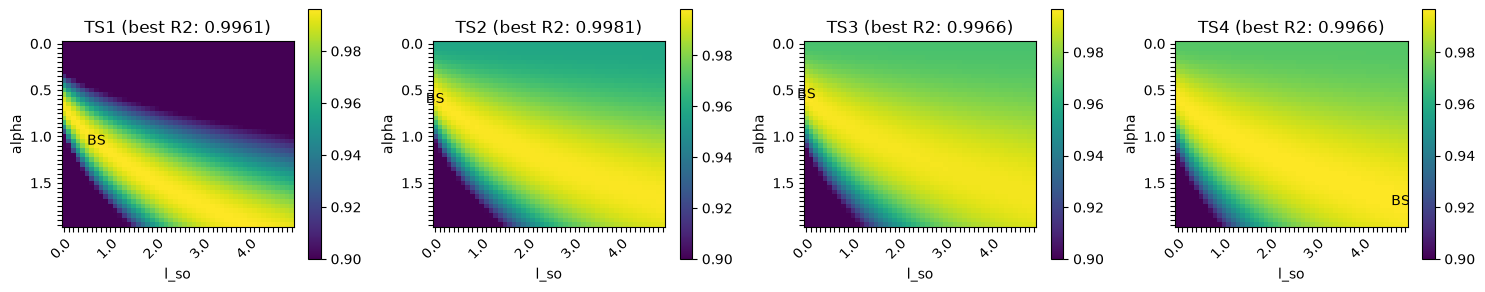

In [8]:
# heatmaps 
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(15,3))
for ax, exp_name in zip(axs.flatten(), experiments):
    best = max(r2_score_grid[exp_name].flatten())
    im=ax.imshow(r2_score_grid[exp_name], vmin=0.9)
    ax.set_title(f'{exp_name} (best R2: {best:.4f})' )
    for i in range(len(alpha_range)):
        for j in range(len(l_so_range)):
            if r2_score_grid[exp_name][i, j]==best:
                text = ax.text(j, i, 'BS',
                        ha="center", va="center")
            
    # Show all ticks and label them with the respective list entries
    ax.set_xticks(range(len(l_so_range)), labels=[f'{x:.1f}' if i%10==0 else None for i, x in enumerate(l_so_range)],
                rotation=45, ha="right", rotation_mode="anchor")
    ax.set_xlabel('l_so')
    ax.set_ylabel('alpha')
    ax.set_yticks(range(len(alpha_range)), labels=[f'{x:.1f}' if i%10==0 else None for i, x in enumerate(alpha_range)])
    ax.figure.colorbar(im)

for ax in axs.flatten():
    if not ax.images:
        ax.set_axis_off()

    
fig.tight_layout()
plt.show()

## Shape of curves inside the valley
With varying $\lambda_{SO}$

In [9]:
# curve to plot (-T_c)
t_grid = np.arange(0, 1.0, 0.01)
t_grid[t_grid==0]=1e-9 # instead of 0 temperature

t_curve, h_pauli = model_pauli.curve(t_grid, return_reduced=False)
__, h_fitted = model_fitted.curve(t_grid, return_reduced=False)

C:\Users\chyi\AppData\Local\Temp\ipykernel_30424\910673621.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


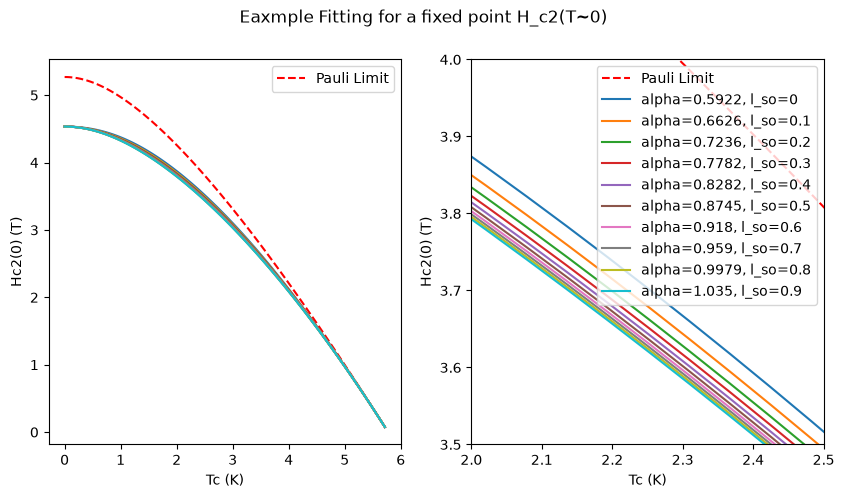

In [10]:
l_so_grid = np.arange(0.0, 1.0, 0.1)


fig, axes  = plt.subplots(1, 2, figsize=(10, 5))

for idx, ax in enumerate(axes):
    ax.plot(t_curve, h_pauli, 'r--', label='Pauli Limit')

    for li in l_so_grid:
        m = WHHModel(**fit_p0 | {"l_so":li})
        resid_f, x0 = m.make_residual(t=t_curve[:1], field=h_fitted[:1], x0=[0.6], fit=['alpha',])
        res = least_squares(resid_f, x0)
        alpha = res.x[0]
        m = WHHModel(**(fit_p0 | {"l_so":li, "alpha": alpha}))
        t_l, h_l = m.curve(t_grid, return_reduced=False)
        label=f'{alpha=:.4g}, l_so={li:.4g}' if idx==1 else None
        ax.plot(t_l, h_l, label=label)
    
    if idx==1:
        plt.xlim(2.0, 2.5)
        plt.ylim(3.5, 4.0)
    ax.legend()
    ax.set_xlabel('Tc (K)')
    ax.set_ylabel('Hc2(0) (T)')
fig.suptitle('Eaxmple Fitting for a fixed point H_c2(T~0)')
fig.show()

Fitted parameters example : {'alpha': 0.592233, 'l_so': 5.372412e-15, 'slope': -1.317696, 't_c': 5.773707}


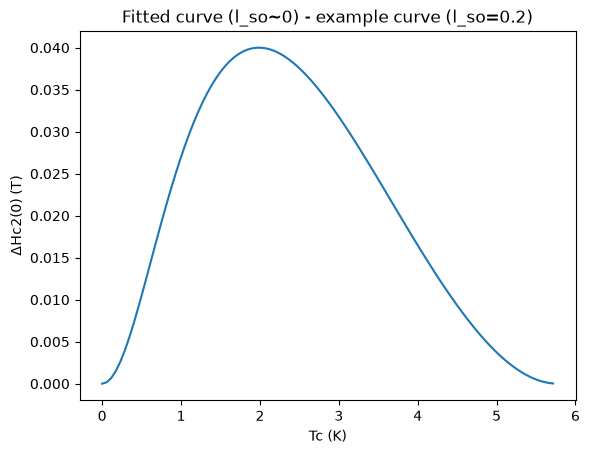

In [11]:
li=0.2
m = WHHModel(**fit_p0 | {"l_so":li})
resid_f, x0 = m.make_residual(t=t_curve[:1], field=h_fitted[:1], x0=[0.6], fit=['alpha',])
res = least_squares(resid_f, x0)
alpha = res.x[0]
m = WHHModel(**(fit_p0 | {"l_so":li, "alpha": alpha}))
t_l, h_l = m.curve(t_grid, return_reduced=False)

plt.plot(t_l, h_fitted - h_l)
plt.title('Fitted curve (l_so~0) - example curve (l_so=0.2)')
plt.xlabel('Tc (K)')
plt.ylabel('ΔHc2(0) (T)')
print(f'Fitted parameters example : {fit_p0}')

***Plotly Version***: Plot `Hc2(T)-T` graphs, compare l_so=0.2 -vs- fitted

```python
    import plotly.graph_objects as go
    fig = go.Figure()
    l_so_grid = np.arange(0.0, 1, 0.1)
    h_by_l = []

    fig.add_trace(go.Scatter(x=t_curve, y=h_pauli, mode='lines+markers', name='pauli_limit'))
    fig.add_trace(go.Scatter(x=t_curve, y=h_fitted, mode='lines+markers', name='h_fitted'))

    for li in l_so_grid:
        m = WHHModel(**fit_p0 | {"l_so":li})
        resid_f, x0 = m.make_residual(t=t_curve[:1], field=h_fitted[:1], x0=[0.6], fit=['alpha',])
        res = least_squares(resid_f, x0)
        alpha = res.x[0]
        m = WHHModel(**(fit_p0 | {"l_so":li, "alpha": alpha}))
        t_l, h_l = m.curve(t_grid, return_reduced=False)
        label=f'{alpha=:.4f}, l_so={li}'
        fig.add_trace(go.Scatter(x=t_l, y=h_l, mode='lines', name=label))
    fig.show()
```

Difference of $\Delta H_{c2}-T$ curves

```python
    # compare l_so=0.2 -vs- fitted
    fig = go.Figure()

    li=0.2
    m = WHHModel(**fit_p0 | {"l_so":li})
    resid_f, x0 = m.make_residual(t=t_curve[:1], field=h_fitted[:1], x0=[0.6], fit=['alpha',])
    res = least_squares(resid_f, x0)
    alpha = res.x[0]
    m = WHHModel(**(fit_p0 | {"l_so":li, "alpha": alpha}))
    t_l, h_l = m.curve(t_grid, return_reduced=False)
    label=f'{alpha=:.4f}, l_so={li}-fitted'
    fig.add_trace(go.Scatter(x=t_l, y=h_fitted-h_l, mode='lines', name=label))
    fig.show()
```

# Fitting Kim et al. 2025

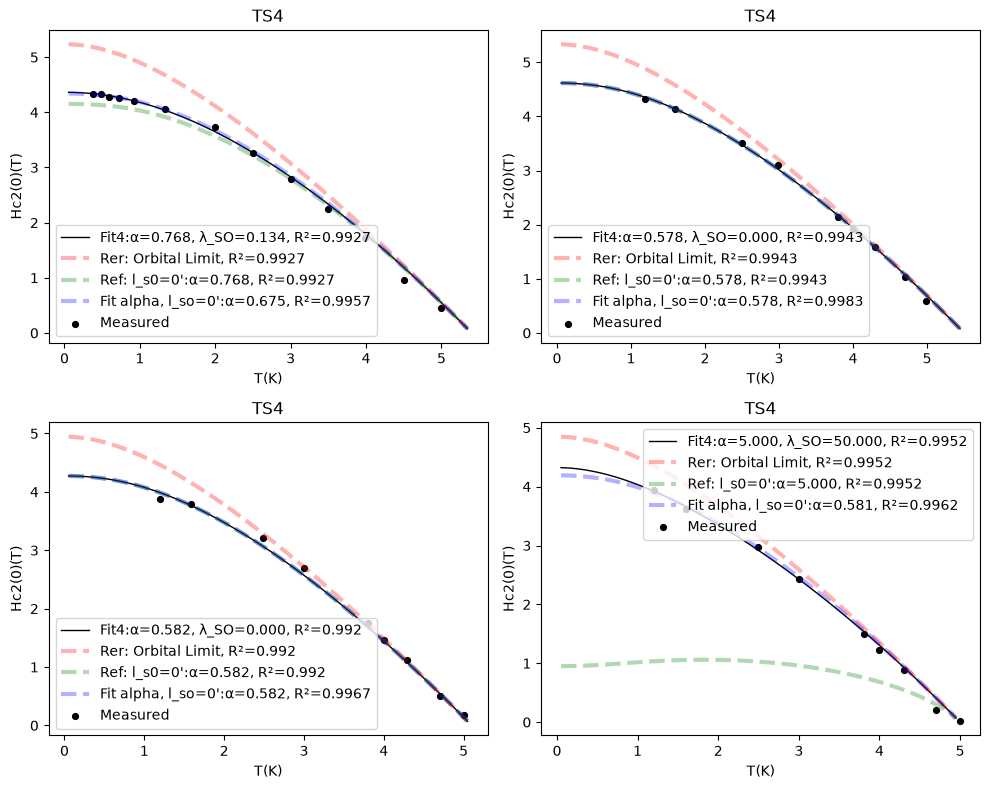

In [12]:
symbols=['*', '+', 'p', '.', '1','o','p','s','x']
ref_formats = ['r--', 'g--', 'b--']
n = 99
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

for ax, exp in zip(axs.flatten(), ['TS1', 'TS2', 'TS3', 'TS4']):
    ci=0

    measured_df = meta_df.loc[exp]
    obs_df = data_df[data_df['exp_name']==exp]
    t_obs = obs_df['t'].to_numpy()
    h_obs = obs_df['field'].to_numpy()
    fixed_params = {fp: measured_df[fp] for fp in fixed}

    m = WHHModel(**fixed_params)
    res_f, x0 = m.make_residual(t_obs, h_obs, fit=fit, x0=(0.5, 0.5))
    fit_res = least_squares(res_f, x0, bounds=[[0, 0], [5, 100]])
    fitted_params = {k:v for k, v in zip(fit, fit_res.x)}

    t_scaled = t_obs / fixed_params['t_c']
    r2_score = m.score(t_scaled, h_obs, alpha=a, l_so=l_so)['r2']

    grid = np.linspace(0.01, 0.99, n)
    raw_t_grid = grid*fixed_params['t_c']


    # fitted curves
    label=f"Fit4:α={fitted_params['alpha']:.3f}, λ_SO={fitted_params['l_so']:.3f}, R²={r2_score:.4g}"
    curve_m = WHHModel(**fixed_params, **fitted_params)
    _, curve_h = curve_m.curve(grid, return_reduced=False)
    ax.plot(raw_t_grid, curve_h, 'k-', label=label, linewidth=1)


    # reference line 1. orbital limit
    curve_m = WHHModel(**fixed_params, l_so=0, alpha=0)
    fitted_params = {k:v for k, v in zip(fit, fit_res.x)}
    r2_score = curve_m.score(t_scaled, h_obs, alpha=a, l_so=l_so)['r2']
    label=f"Rer: Orbital Limit, R²={r2_score:.4g}"
    _, curve_h =curve_m.curve(grid, return_reduced=False)
    ax.plot(raw_t_grid, curve_h, ref_formats[ci], label=label, linewidth=3, alpha=0.3)
    ci+=1

    # reference line 2. l_so=0 with fitted alpha

    curve_m = WHHModel(**fixed_params, **fitted_params|{"l_so":0})
    fitted_params = {k:v for k, v in zip(fit, fit_res.x)}
    r2_score = curve_m.score(t_scaled, h_obs, alpha=a, l_so=l_so)['r2']
    label=f"Ref: l_s0=0':α={fitted_params['alpha']:.3f}, R²={r2_score:.4g}"
    _, curve_h = curve_m.curve(grid, return_reduced=False)
    ax.plot(raw_t_grid, curve_h, ref_formats[ci], label=label, linewidth=3, alpha=0.3)
    ci+=1

    # Fix l_so=0, fit alpha only
    fit_alpha_m = WHHModel(**fixed_params, l_so=0)
    res_f, x0 = fit_alpha_m.make_residual(t_obs, h_obs, fit=['alpha',], x0=[0.5,])
    fit_res = least_squares(res_f, x0, bounds=[[0], [5]])
    a1 = fit_res.x[0]

    t_scaled = t_obs / fixed_params['t_c']
    curve_m = WHHModel(**fixed_params, alpha=a1, l_so=0)

    r2_score = curve_m.score(t_scaled, h_obs, alpha=a1)['r2']
    label=f"Fit alpha, l_so=0':α={a1:.3f}, R²={r2_score:.4g}"
    _, curve_h = curve_m.curve(grid, return_reduced=False)
    ax.plot(raw_t_grid, curve_h, ref_formats[ci], label=label, linewidth=3, alpha=0.3)
    ci+=1

    # plot measured
    ax.scatter(t_obs, h_obs, c='k', marker='.', s=70, label="Measured")
    ax.set_title(exp_name)
    ax.legend()
    ax.set_xlabel('T(K)')
    ax.set_ylabel('Hc2(0)(T)')

fig.tight_layout()
plt.show()